In [1]:
import cv2
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torchvision.transforms as T
from torchvision import transforms
from sklearn.metrics.pairwise import cosine_similarity
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

from sklearn.decomposition import PCA

/home/vtqn/projects/sotatek-assessment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DRAWING_PATH = "examples/drawing.png"
PATTERN_PATH = "examples/pattern1.png"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SIMILARITY_THRESHOLD = 0.75

MIN_COMPONENT_AREA = 100
MAX_COMPONENT_AREA = 100000

INPUT_SIZE = 518

In [3]:
def display(images, titles=None, is_binary=False):
    n = len(images)

    width_ratios = [1] + [5] * (n - 1)

    fig = plt.figure(figsize=(5 * n, 5))
    gs = fig.add_gridspec(1, n, width_ratios=width_ratios)

    for i, img in enumerate(images):
        ax = fig.add_subplot(gs[i])
        ax.imshow(img, cmap="gray" if is_binary else None)

        if titles:
            ax.set_title(titles[i], fontsize=20)

        ax.axis("off")

    plt.tight_layout()
    plt.show()

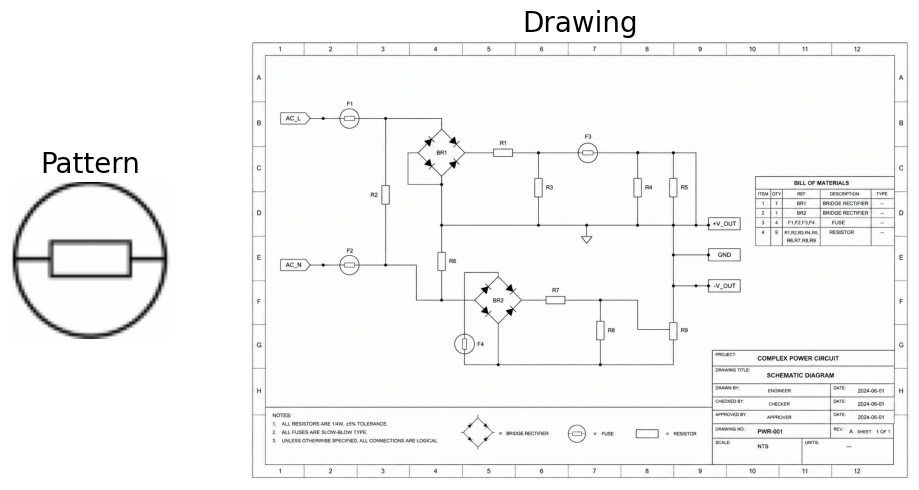

In [4]:
drawing = cv2.imread(DRAWING_PATH)
pattern = cv2.imread(PATTERN_PATH)

# Verify images loaded correctly
if drawing is None:
    raise ValueError(f"Failed to load drawing image: {DRAWING_PATH}")

if pattern is None:
    raise ValueError(f"Failed to load pattern image: {PATTERN_PATH}")

# Convert BGR -> RGB
drawing_rgb = cv2.cvtColor(drawing, cv2.COLOR_BGR2RGB)
pattern_rgb = cv2.cvtColor(pattern, cv2.COLOR_BGR2RGB)

# Display
display([pattern_rgb, drawing_rgb], titles=["Pattern", "Drawing"])

Using cache found in /home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main
/home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


(1024, 1536, 3)
Extracted tokens shape: torch.Size([1536, 384])
Original tokens shape: (1536, 384)
Grid size: (32, 48)
image.shape: (1024, 1536, 3)
image_tensor.shape: torch.Size([3, 448, 672])
grid_size: (32, 48)
resize_scale: 2.2857142857142856
features.shape: (1536, 384)


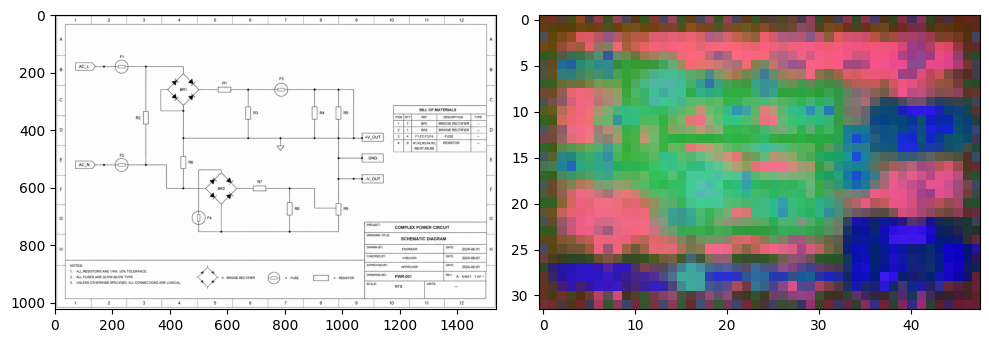

In [5]:
class Dinov2Matcher:

  def __init__(self, repo_name="facebookresearch/dinov2", model_name="dinov2_vits14", smaller_edge_size=448, half_precision=False, device="cuda"):
    self.repo_name = repo_name
    self.model_name = model_name
    self.smaller_edge_size = smaller_edge_size
    self.half_precision = half_precision
    self.device = device

    if self.half_precision:
      self.model = torch.hub.load(repo_or_dir=repo_name, model=model_name).half().to(self.device)
    else:
      self.model = torch.hub.load(repo_or_dir=repo_name, model=model_name).to(self.device)

    self.model.eval()

    self.transform = transforms.Compose([
        transforms.Resize(size=smaller_edge_size, interpolation=transforms.InterpolationMode.BICUBIC, antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # imagenet defaults
      ])

  # https://github.com/facebookresearch/dinov2/blob/255861375864acdd830f99fdae3d9db65623dafe/notebooks/features.ipynb
  def prepare_image(self, rgb_image_numpy):
    image = Image.fromarray(rgb_image_numpy)
    image_tensor = self.transform(image)
    resize_scale = image.width / image_tensor.shape[2]

    # Crop image to dimensions that are a multiple of the patch size
    height, width = image_tensor.shape[1:] # C x H x W
    cropped_width, cropped_height = width - width % self.model.patch_size, height - height % self.model.patch_size # crop a bit from right and bottom parts
    image_tensor = image_tensor[:, :cropped_height, :cropped_width]

    grid_size = (cropped_height // self.model.patch_size, cropped_width // self.model.patch_size)
    return image_tensor, grid_size, resize_scale
  
  def prepare_mask(self, mask_image_numpy, grid_size, resize_scale):
    cropped_mask_image_numpy = mask_image_numpy[:int(grid_size[0]*self.model.patch_size*resize_scale), :int(grid_size[1]*self.model.patch_size*resize_scale)]
    image = Image.fromarray(cropped_mask_image_numpy)
    resized_mask = image.resize((grid_size[1], grid_size[0]), resample=Image.Resampling.NEAREST)
    resized_mask = np.asarray(resized_mask).flatten()
    return resized_mask
  
  def extract_features(self, image_tensor):
    with torch.inference_mode():
      if self.half_precision:
        image_batch = image_tensor.unsqueeze(0).half().to(self.device)
      else:
        image_batch = image_tensor.unsqueeze(0).to(self.device)

      tokens = self.model.get_intermediate_layers(image_batch)[0].squeeze()

    print("Extracted tokens shape:", tokens.shape)
    return tokens.cpu().numpy()
  
  def idx_to_source_position(self, idx, grid_size, resize_scale):
    row = (idx // grid_size[1])*self.model.patch_size*resize_scale + self.model.patch_size / 2
    col = (idx % grid_size[1])*self.model.patch_size*resize_scale + self.model.patch_size / 2
    return row, col
  
  def get_embedding_visualization(self, tokens, grid_size):
    print("Original tokens shape:", tokens.shape)
    print("Grid size:", grid_size)
    pca = PCA(n_components=3)
    reduced_tokens = pca.fit_transform(tokens.astype(np.float32))
    reshaped_reduced_tokens = reduced_tokens.reshape((*grid_size, -1))
    normalized_tokens = (reshaped_reduced_tokens-np.min(reshaped_reduced_tokens))/(np.max(reshaped_reduced_tokens)-np.min(reshaped_reduced_tokens))
    return reduced_tokens, normalized_tokens

# Init Dinov2Matcher
dm = Dinov2Matcher(half_precision=False)

image = drawing_rgb

print(image.shape)

# Extract features
image_tensor, grid_size, resize_scale = dm.prepare_image(image)
features = dm.extract_features(image_tensor)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,20))
ax1.imshow(image)
reduced_tokens, vis_image = dm.get_embedding_visualization(features, grid_size)
ax2.imshow(vis_image)
fig.tight_layout()

# More info
print("image.shape:", image.shape)
print("image_tensor.shape:", image_tensor.shape)
print("grid_size:", grid_size)
print("resize_scale:", resize_scale)
print("features.shape:", features.shape)

In [ ]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = km.fit_predict(reduced_tokens)

# Content cluster = higher mean feature norm
# norms = np.linalg.norm(features, axis=1)
# mean_norm = [norms[labels == k].mean() for k in range(2)]
# content_cluster = int(np.argmax(mean_norm))
# print(f"Content cluster={content_cluster}, mean norms: {mean_norm}")
content_mask_flat = (labels == 2)
content_mask_2d   = content_mask_flat.reshape(grid_size[0], grid_size[1])

In [ ]:
def visualize_mask(drawing_rgb, content_mask_2d, draw_grid, draw_scale, patch_size=14):
    """Show the content mask overlaid on the drawing (Step 2 debug)."""
    gh, gw = draw_grid
    ph = int(gh * patch_size * draw_scale)
    pw = int(gw * patch_size * draw_scale)
    mask_img = (content_mask_2d.astype(np.uint8) * 255)
    mask_big = cv2.resize(mask_img, (pw, ph), interpolation=cv2.INTER_NEAREST)
    h, w = drawing_rgb.shape[:2]
    crop = drawing_rgb[:min(h, ph), :min(w, pw)].copy()
    overlay = crop.copy()
    m = mask_big[:crop.shape[0], :crop.shape[1]] > 0

    ys, xs = np.where(m)

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    print("Top-left:    ", (x_min, y_min))
    print("Bottom-right:", (x_max, y_max))
    cropped = drawing_rgb[y_min:y_max+1, x_min:x_max+1]

    overlay[m] = [100, 220, 100]
    blended = cv2.addWeighted(crop, 0.55, overlay, 0.45, 0)

    fig, axes = plt.subplots(1, 3, figsize=(14, 6))
    axes[0].imshow(vis_image); axes[0].set_title("PCA"); axes[0].axis("off")
    axes[1].imshow(blended);     axes[1].set_title("Content mask (green)"); axes[1].axis("off")
    axes[2].imshow(cropped);     axes[2].set_title("Cropped"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

In [ ]:
for k in range(3):
    print(f"Cluster {k}: {(labels == k).sum()} patches")
    content_mask_flat = (labels == k)
    content_mask_2d   = content_mask_flat.reshape(grid_size[0], grid_size[1])
    visualize_mask(drawing_rgb, content_mask_2d, grid_size, resize_scale, dm.model.patch_size)

In [ ]:
from PIL import Image
import json
from dino_pattern_detector import DinoPatternDetector, ImageWrapper
from utils import resize_with_scale, turn_to_binary, crop_to_foreground
import torch
import time

detector = DinoPatternDetector(model_name="dinov2_vitb14", device="cuda")

pattern_image = Image.open("examples/pattern.png")
drawing_image = Image.open("examples/drawing.png")
start_time = time.time()
detections, viz = detector.detect(
    pattern_image=pattern_image,
    drawing_image=drawing_image,
    drawing_scales=[1],
    threshold_percentile=99.0,
    nms_iou_threshold=0.05,
    max_detections=30,
    debug=True,
)
end_time = time.time()
print(f"Detection time: {end_time - start_time:.2f} seconds")
viz.save("output.png")

Creating rotated image for non-square pattern...
(5, 5)
[[False  True  True False False]
 [False  True  True False False]
 [False  True  True False False]
 [False  True  True False False]
 [False  True  True False False]]


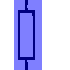

In [2]:
from PIL import Image
from dino_pattern_detector import ImageWrapper
from utils import turn_to_binary, crop_to_foreground, display_overlay

test_pattern_image = Image.open("examples/pattern2.png").convert("RGB")
image_wrapper = ImageWrapper(test_pattern_image, patch_size=14, resize_option="resize", pattern_grid_size_check=True)

if not image_wrapper.is_originally_square:
    print("Creating rotated image for non-square pattern...")
    rotated_image = image_wrapper.image.transpose(method=Image.Transpose.ROTATE_90)
    rotated_image_wrapper = ImageWrapper(
        rotated_image,
        patch_size=14,
        resize_option="resize",
        pattern_grid_size_check=True)
else:
    rotated_image_wrapper = image_wrapper

print(rotated_image_wrapper.grid_size)
mask = rotated_image_wrapper.get_token_mask().numpy()

result = display_overlay(mask, rotated_image_wrapper.image)

print(mask)
result.show()

(336, 224)
Using device: cuda


Using cache found in /home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main
/home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


(24, 16)
Tokens shape: torch.Size([384, 384]), Features shape: torch.Size([16, 24, 384])
features.shape: torch.Size([16, 24, 384])
flat_features.shape: torch.Size([384, 384])
gw, gh: 24 16


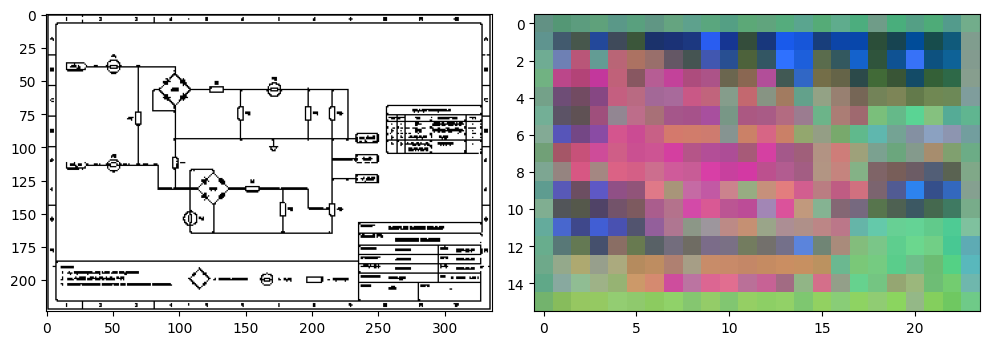

In [1]:
from PIL import Image
from dino_pattern_detector import ImageWrapper, DinoPatternDetector
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from utils import resize_with_scale


test_pattern_image = Image.open("examples/drawing.png").convert("RGB")
image_wrapper = ImageWrapper(resize_with_scale(test_pattern_image, scale=0.22), patch_size=14, resize_option="resize")

print(image_wrapper.image.size) #[w, h]

def get_embedding_visualization(tokens, grid_size):
    pca = PCA(n_components=3)
    reduced_tokens = pca.fit_transform(tokens.astype(np.float32))
    reshaped_reduced_tokens = reduced_tokens.reshape((*grid_size, -1))
    normalized_tokens = (reshaped_reduced_tokens-np.min(reshaped_reduced_tokens))/(np.max(reshaped_reduced_tokens)-np.min(reshaped_reduced_tokens))
    return reduced_tokens, normalized_tokens

detector = DinoPatternDetector(model_name="dinov2_vits14", device="cuda")
print(image_wrapper.grid_size) #[w, h]
features = detector.extract_features(image_wrapper).detach().cpu() # [h, w, d]
h, w, d = features.shape
print("features.shape:", features.shape)
flat_features = features.reshape(h * w, d)  # [7957, 384]
print("flat_features.shape:", flat_features.shape)


gw, gh = image_wrapper.grid_size
print("gw, gh:", gw, gh)
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,20))
ax1.imshow(image_wrapper.image)
reduced_tokens, vis_image = get_embedding_visualization(flat_features.cpu().numpy(), (gh, gw))
ax2.imshow(vis_image)
fig.tight_layout()
plt.show()

In [2]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize


def find_roi(
    features_np: np.ndarray,
    image_size: tuple, #[w, h]
    patch_size=14,
    n_clusters=3,
    center_xy=None,
    min_component_area=5,
    keep_top_k_components=None,
    margin_tokens=0,
    l2_normalize=True,
):
    """
    KMeans center-cluster ROI, but ignore outlier islands.

    Steps:
    1. KMeans directly on DINO features
    2. Get center token's label
    3. Make mask of all tokens with that label
    4. Remove small connected components
    5. Take bbox of remaining tokens
    6. Convert bbox back to image coordinates by * patch_size

    Args:
        features: [H_tokens, W_tokens, D]
        image: PIL.Image
        patch_size: usually 14 for DINOv2 ViT/14
        n_clusters: KMeans cluster count
        center_xy: optional pixel-space point (x, y), default image center
        min_component_area: remove connected components smaller than this token count
        keep_top_k_components:
            - None: keep all components >= min_component_area
            - int: keep only top-k largest valid components
        margin_tokens: expand bbox by this many tokens
        l2_normalize: normalize features before KMeans

    Returns:
        roi: (x1, y1, x2, y2)
        debug: dict
    """

    h_tokens, w_tokens, d = features_np.shape
    flat_features = features_np.reshape(-1, d).astype(np.float32)

    if l2_normalize:
        flat_features = normalize(flat_features, norm="l2", axis=1)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=0,
        n_init=10,
    )

    flat_labels = kmeans.fit_predict(flat_features)
    labels = flat_labels.reshape(h_tokens, w_tokens)

    # Center token
    if center_xy is None:
        cx_token = w_tokens // 2
        cy_token = h_tokens // 2
    else:
        cx, cy = center_xy
        cx_token = int(cx / patch_size)
        cy_token = int(cy / patch_size)
        cx_token = np.clip(cx_token, 0, w_tokens - 1)
        cy_token = np.clip(cy_token, 0, h_tokens - 1)

    center_label = labels[cy_token, cx_token]

    # Mask of selected cluster
    cluster_mask = (labels == center_label).astype(np.uint8)

    # Connected components on token grid
    num_cc, cc_map, stats, _ = cv2.connectedComponentsWithStats(
        cluster_mask,
        connectivity=8,
    )

    valid_components = []

    for cc_id in range(1, num_cc):
        area = stats[cc_id, cv2.CC_STAT_AREA]

        if area >= min_component_area:
            valid_components.append((cc_id, area))

    # Fallback: if filtering removed everything, use original cluster mask
    if len(valid_components) == 0:
        clean_mask = cluster_mask.copy()
    else:
        valid_components = sorted(
            valid_components,
            key=lambda x: x[1],
            reverse=True,
        )

        if keep_top_k_components is not None:
            valid_components = valid_components[:keep_top_k_components]

        clean_mask = np.zeros_like(cluster_mask)

        for cc_id, area in valid_components:
            clean_mask[cc_map == cc_id] = 1

    ys, xs = np.where(clean_mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return (0, 0, image_size[0], image_size[1]), {
            "labels": labels,
            "center_label": center_label,
            "cluster_mask": cluster_mask,
            "clean_mask": clean_mask,
            "center_token": (cx_token, cy_token),
        }

    x_min_token = max(0, xs.min() - margin_tokens)
    x_max_token = min(w_tokens - 1, xs.max() + margin_tokens)
    y_min_token = max(0, ys.min() - margin_tokens)
    y_max_token = min(h_tokens - 1, ys.max() + margin_tokens)

    x1 = int(x_min_token * patch_size)
    y1 = int(y_min_token * patch_size)
    x2 = int((x_max_token + 1) * patch_size)
    y2 = int((y_max_token + 1) * patch_size)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(image_size[0], x2)
    y2 = min(image_size[1], y2)

    roi = (x1, y1, x2, y2)

    debug = {
        "labels": labels,
        "center_label": center_label,
        "cluster_mask": cluster_mask,
        "clean_mask": clean_mask,
        "center_token": (cx_token, cy_token),
        "token_bbox": (
            x_min_token,
            y_min_token,
            x_max_token,
            y_max_token,
        ),
        "valid_components": valid_components,
    }

    return roi, debug



In [5]:
roi, debug = find_roi(
    features.detach().cpu().numpy(),
    image_wrapper.image_size, #[w, h]
    patch_size=14,
    n_clusters=3,
    min_component_area=8,
    keep_top_k_components=None,
    margin_tokens=0,
)

print("ROI coordinates (x1, y1, x2, y2):", roi)
print("Image size (w, h):", image_wrapper.image_size)

print("ROI:", roi)
print("Center label:", debug["center_label"])
print("Token bbox:", debug["token_bbox"])
print("Valid components:", debug["valid_components"])

ROI coordinates (x1, y1, x2, y2): (14, 28, 252, 210)
Image size (w, h): (336, 224)
ROI: (14, 28, 252, 210)
Center label: 1
Token bbox: (np.int64(1), np.int64(2), np.int64(17), np.int64(14))
Valid components: [(1, np.int32(127))]


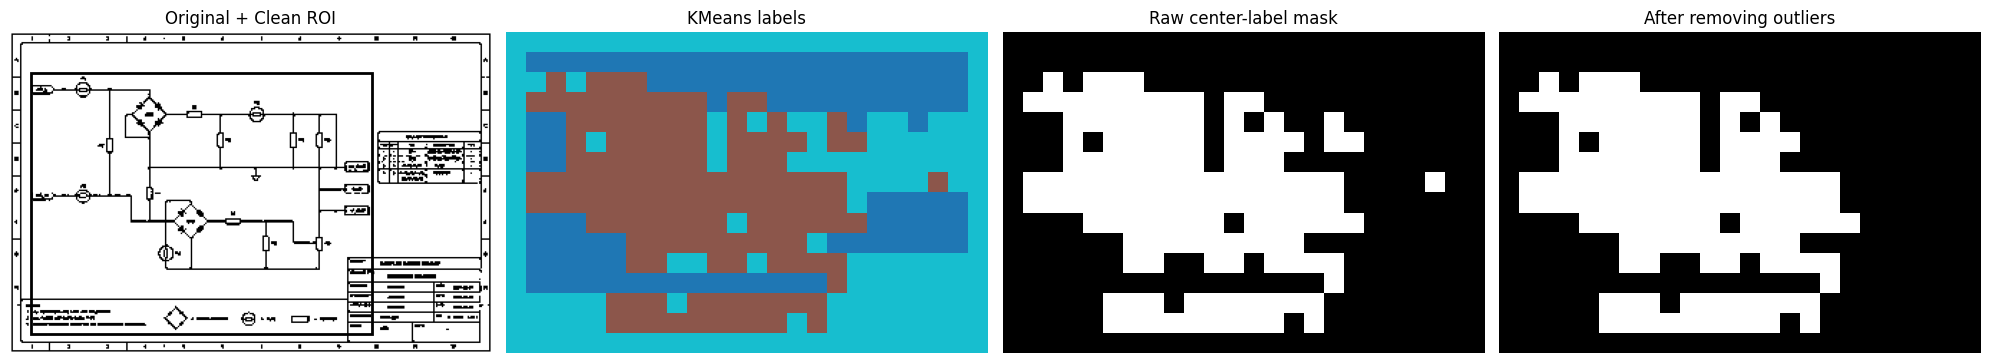

In [4]:
import matplotlib.pyplot as plt

x1, y1, x2, y2 = roi

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_wrapper.image)
axes[0].add_patch(
    plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2,
    )
)
axes[0].set_title("Original + Clean ROI")

axes[1].imshow(debug["labels"], cmap="tab10")
axes[1].set_title("KMeans labels")

axes[2].imshow(debug["cluster_mask"], cmap="gray")
axes[2].set_title("Raw center-label mask")

axes[3].imshow(debug["clean_mask"], cmap="gray")
axes[3].set_title("After removing outliers")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()